# What is `torch.nn` really?

Based on https://docs.pytorch.org/tutorials/beginner/nn_tutorial.html

This tutorial peels back the mask from high-level abstractions in `torch.nn`, `torch.optim`, etc. by training a neural net without them, then introducing them gradually to demonstrate how they fit.

## MNIST data setup

MNIST: https://yann.lecun.com/exdb/mnist/index.html

In [2]:
from pathlib import Path
import requests

In [3]:
DATA_PATH = Path("data")
PATH = DATA_PATH / "mnist"

PATH.mkdir(parents=True, exist_ok=True)

URL = "https://github.com/pytorch/tutorials/raw/main/_static/"
FILENAME = "mnist.pkl.gz"

if not (PATH / FILENAME).exists():
    content = requests.get(URL + FILENAME).content
    (PATH / FILENAME).open("wb").write(content)

In [4]:
# This dataset is in numpy array format, and has been stored using pickle

import pickle
import gzip

with gzip.open((PATH / FILENAME).as_posix(), "rb") as f:
    ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")

C:\Users\clhabins\AppData\Local\Temp\ipykernel_63000\607019417.py:7: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")


Each image is 28 x 28, and is being stored as a flattened row of length 784 (=28x28). Let’s take a look at one; we need to reshape it to 2d first.

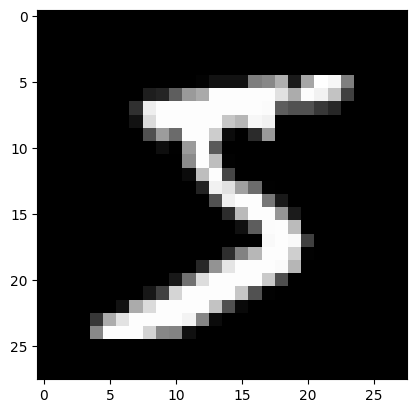

(50000, 784)


In [5]:
from matplotlib import pyplot
import numpy as np

pyplot.imshow(x_train[0].reshape((28, 28)), cmap="gray")
# ``pyplot.show()`` only if not on Colab
try:
    import google.colab
except ImportError:
    pyplot.show()
print(x_train.shape)

In [6]:
# PyTorch uses torch.tensor, rather than numpy arrays, so we need to convert our data.

import torch

x_train, y_train, x_valid, y_valid = map(
    torch.tensor, (x_train, y_train, x_valid, y_valid)
)

n, c = x_train.shape
print(x_train, y_train)
print(x_train.shape)
print(y_train.min(), y_train.max())

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]) tensor([5, 0, 4,  ..., 8, 4, 8])
torch.Size([50000, 784])
tensor(0) tensor(9)


## Neural net from scratch (without `torch.nn`)

Let’s first create a model using nothing but PyTorch tensor operations.

PyTorch provides methods to create random or zero-filled tensors, which we will use to create our weights and bias for a simple linear model. These are just regular tensors, with one very special addition: we tell PyTorch that they require a gradient. This causes PyTorch to record all of the operations done on the tensor, so that it can calculate the gradient during back-propagation automatically!

For the weights, we set `requires_grad` **after** the initialization, since we don’t want that step included in the gradient. (Note that a trailing _ in PyTorch signifies that the operation is performed in-place.)

*Note*: We are initializing the weights here with [Xavier initialisation](http://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf) (by multiplying with `1/sqrt(n)`).

In [7]:
import math

weights = torch.randn(784, 10) / math.sqrt(784)
weights.requires_grad_()
bias = torch.zeros(10, requires_grad=True)

Thanks to PyTorch’s ability to calculate gradients automatically, we can use any standard Python function (or callable object) as a model!

So let’s just write a plain matrix multiplication and broadcasted addition to create a simple linear model. We also need an activation function, so we’ll write log_softmax and use it.

Although PyTorch provides lots of prewritten loss functions, activation functions, and so forth, you can easily write your own using plain python. PyTorch will even create fast accelerator or vectorized CPU code for your function automatically.

In [8]:
def log_softmax(x):
    return x - x.exp().sum(-1).log().unsqueeze(-1)

def model(xb):
    return log_softmax(xb @ weights + bias)

In the above, the `@` stands for the matrix multiplication operation.

We will call our function on one batch of data (in this case, 64 images). This is one forward pass. Note that our predictions won’t be any better than random at this stage, since we start with random weights.

In [9]:
bs = 64 # batch size

xb = x_train[0:bs] # a mini-batch from x
preds = model(xb) # predictions
print(preds[0], preds.shape)


tensor([-1.7953, -2.4315, -2.4446, -2.4137, -2.2937, -2.4506, -2.5034, -1.9761,
        -2.6281, -2.4077], grad_fn=<SelectBackward0>) torch.Size([64, 10])


As you see, the preds tensor contains not only the tensor values, but also a gradient function. We’ll use this later to do backprop.

Let’s implement negative log-likelihood to use as the loss function (again, we can just use standard Python):

In [10]:
def nll(input, target):
    # input has shape (batch_size, num_classes)
    # target has shape (batch_size,)
    # values of target are 0 to num_classes - 1
    # So the following is equivalent to
    # -input[[0, 1, 2, ...], [y0, y1, y2, ...]].mean()
    # For each input item, take the item whose index matches the target class
    # If an input row contains the predicted probability for each class
    # in the columns, the selecting the column corresponding to the
    # target class returns the likelihood of getting the right
    # answer. We want to maximize this likelihood.
    # Or minimize the negative likelihood.
    # Instead of actual probabilities, we use log for
    # better numerical stability on computers
    # (better to add logs than multiply really small numbers which risks precision loss).
    # That returns shape (batch_size)
    # Then we take the mean across the batch.
    return -input[range(target.shape[0]), target].mean()

loss_func = nll

Let’s check our loss with our random model, so we can see if we improve after a backprop pass later.

In [11]:
yb = y_train[0:bs]
print(loss_func(preds, yb))

tensor(2.4346, grad_fn=<NegBackward0>)


Let’s also implement a function to calculate the accuracy of our model.

For each prediction, if the index with the largest value matches the target value, then the prediction was correct.

In [12]:
def accuracy(out, yb):
    preds = torch.argmax(out, dim=1)
    return (preds == yb).float().mean()

In [13]:
print(accuracy(preds, yb))

tensor(0.0312)


We can now run a training loop. For each iteration, we will:

- select a mini-batch of data (of size bs)
- use the model to make predictions
- calculate the loss
- `loss.backward()` updates the gradients of the model, in this case, weights and bias.

We now use these gradients to update the weights and bias. We do this within the `torch.no_grad()` context manager, because we do not want these actions to be recorded for our next calculation of the gradient. You can read more about how PyTorch’s Autograd records operations [here](https://pytorch.org/docs/stable/notes/autograd.html).

We then set the gradients to zero, so that we are ready for the next loop. Otherwise, our gradients would record a running tally of all the operations that had happened (i.e. `loss.backward()` adds the gradients to whatever is already stored, rather than replacing them).

**Tip**: You can use the standard python debugger to step through PyTorch code, allowing you to check the various variable values at each step. Uncomment `set_trace()` below to try it out.

In [14]:
from IPython.core.debugger import set_trace

lr = 0.5 # learning_rate
epochs = 2 # how many epochs to train for

for epoch in range(epochs):
    print("Epoch", epoch)
    for i in range((n - 1) // bs + 1):
        # set_trace()
        start_i = i * bs
        end_i = start_i + bs
        xb = x_train[start_i: end_i]
        yb = y_train[start_i: end_i]

        pred = model(xb)
        loss = loss_func(pred, yb)

        # computes gradient for each
        # weight in the model
        loss.backward()

        # no grad so these computations
        # are not recorded for the next gradient
        # calculation
        with torch.no_grad():
            weights -= weights.grad * lr
            bias -= bias.grad * lr
            # reset grads so we don't "pollute"
            # next batch.
            weights.grad.zero_()
            bias.grad.zero_()



Epoch 0
Epoch 1


That’s it: we’ve created and trained a minimal neural network (in this case, a logistic regression, since we have no hidden layers) entirely from scratch!

Let’s check the loss and accuracy and compare those to what we got earlier. We expect that the loss will have decreased and accuracy to have increased, and they have.

In [15]:

print(loss_func(model(xb), yb), accuracy(model(xb), yb))

tensor(0.0793, grad_fn=<NegBackward0>) tensor(1.)


## Using `torch.nn.functional`

In [17]:
import torch.nn.functional as F # Contains useful functions, wide range of loss and activation functions, helpers for creating neural nets like pooling, etc. Other parts the library contain classes.

loss_func = F.cross_entropy # cross_entropy combines negative log likelihood and log softmax activation, so we can remove the log_softmax activation part from our model definition since it'll be handled by cross_entropy

def model(xb):
    return xb @ weights + bias

In [18]:
# Let's confirm that our loss and accuracy are the same as before

print(loss_func(model(xb), yb), accuracy(model(xb), yb))

tensor(0.0793, grad_fn=<NllLossBackward0>) tensor(1.)


## Refactoring using `nn.Module`

In [21]:
from torch import nn

class Mnist_Logistic(nn.Module):
    def __init__(self):
        super().__init__()
        ## nn.Parameter is a subclass of torch.Tensor that is treated specially when
        # used as an attribute of nn.Module. It gets automatically added to the module's .parameters() collection.
        # requires_grad also defaults to True.
        # Ordinary tensors are not added to parameters()
        self.weights = nn.Parameter(torch.randn(784, 10) / math.sqrt(784))
        self.bias = nn.Parameter(torch.zeros(10))
    
    def forward(self, xb):
        return xb @ self.weights + self.bias

In [22]:
model = Mnist_Logistic()

In [23]:
# Module instances are callable, when call, they execute the forward() method
print(loss_func(model(xb), yb))

tensor(2.4997, grad_fn=<NllLossBackward0>)


Previously for our training loop we had to update the values for each parameter by name, and manually zero out the grads for each parameter separately
Now we can take advantage of model.parameters() and model.zero_grad() (which are both defined by PyTorch for nn.Module) to make those steps more concise and
less prone to the error of forgetting some of our parameters, particularly if we had a more complicated model:

```python
with torch.no_grad():
    for p in model.parameters():
        p -= p.grad * lr
    model.zero_grad()
```

In [28]:
# Let's wrap the training loop in a fit function

def fit():
    for epoch in range(epochs):
        for i in range((n - 1) // bs + 1):
            start_i = i * bs
            end_i = start_i + bs
            xb = x_train[start_i:end_i]
            yb = y_train[start_i:end_i]
            pred = model(xb)
            loss = loss_func(pred, yb)

            loss.backward()
            with torch.no_grad():
                for p in model.parameters():
                    p -= p.grad * lr
                model.zero_grad()

fit()

In [29]:
# Let's verify that loss has gone down

print(loss_func(model(xb), yb))

tensor(0.0812, grad_fn=<NllLossBackward0>)


## Refactor using `nn.Linear`

Instead of manually defining and initializing `self.weights` and `self.bias` and calculating `xb @ self.weights + self.bias`, we will instead use `nn.Linear`,
which does all that for us.

Pytorch has many types of predefined layers that can greatly simplify our code, and often makes it faster too.

In [30]:
class Mnist_Logistic(nn.Module):
    def __init__(self):
        super().__init__()
        self.lin = nn.Linear(784, 10)
    
    def forward(self, xb):
        return self.lin(xb)

In [31]:
model = Mnist_Logistic()
print(loss_func(model(xb), yb))

tensor(2.3612, grad_fn=<NllLossBackward0>)


In [32]:
# Let's train

fit()
print(loss_func(model(xb), yb))

tensor(0.0808, grad_fn=<NllLossBackward0>)


## Refactor using `torch.optim`

PyTorch also has a package with various optimization algorithms, `torch.optim`. We can use the `step` method from our optimizer
to take a forward step (i.e. update model parameter weights), instead of updating each parameter manually

This will allow us to replace our current optimization code:

```python
with torch.no_grad():
    for p in model.parameters():
        p -= p.grad * lr
    model.zero_grad()
```

with:

```python
opt.step()
opt.zero_grad()
```

`optim.zero_grad()` resets the gradient to 0 and we need to call it before computing the gradient for the next minibatch.



In [33]:
from torch import optim

In [34]:
# Create helper function to create our model and optimizer so we can reuse it in the future

def get_model():
    model = Mnist_Logistic()
    return model, optim.SGD(model.parameters(), lr=lr)

model, opt = get_model()
print(loss_func(model(xb), yb))

for epoch in range(epochs):
    for i in range((n - 1) // bs + 1):
        start_i = i * bs
        end_i = start_i + bs
        xb = x_train[start_i:end_i]
        yb = y_train[start_i:end_i]
        pred = model(xb)
        loss = loss_func(pred, yb)

        loss.backward()
        opt.step()
        opt.zero_grad()


print(loss_func(model(xb), yb))

tensor(2.3242, grad_fn=<NllLossBackward0>)
tensor(0.0821, grad_fn=<NllLossBackward0>)


## Refactor using Dataset

PyTorch has an abstract Dataset class. A Dataset can be anything that has a `__len__` function and a `__getitem__` function as a way of indexing into it.
[This tutorial](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html) walks through a nice example of creating a custom `FacialLandmarkDataset` class as a subclass of Dataset.

PyTorch’s [TensorDataset](https://pytorch.org/docs/stable/_modules/torch/utils/data/dataset.html#TensorDataset) is a Dataset wrapping tensors. By defining a length and way of indexing, this also gives us a way to iterate, index, and slice along the first dimension of a tensor. This will make it easier to access both the independent and dependent variables in the same line as we train.

In [35]:
from torch.utils.data import TensorDataset

In [36]:
# Both x_train and y_train can be combined in a single TensorDataset

train_ds = TensorDataset(x_train, y_train)

In [38]:
model, opt = get_model()

for epoch in range(epochs):
    for i in range((n - 1) // bs + 1):
        # We can index the dataset directly
        # and we can get both x and y  to gether
        xb, yb = train_ds[i*bs : i*bs + bs]
        pred = model(xb)
        loss = loss_func(pred, yb)

        loss.backward()
        opt.step()
        opt.zero_grad()

print(loss_func(model(xb), yb))

tensor(0.0819, grad_fn=<NllLossBackward0>)


## Refactor using `DataLoader`

PyTorch’s `DataLoader` is responsible for managing batches.
You can create a `DataLoader` from any `Dataset`. `DataLoader` makes it easier to iterate over batches. Rather than having to use `train_ds[i*bs : i*bs+bs]`, the `DataLoader` gives us each minibatch automatically.

In [39]:
from torch.utils.data import DataLoader

train_ds = TensorDataset(x_train, y_train)
train_dl = DataLoader(train_ds, batch_size=bs)

In [41]:
# Previously, our loop iterated over batches (xb, yb) like this:
for i in range((n-1)//bs + 1):
    xb, yb = train_ds[i*bs : i*bs+bs]
    pred = model(xb)

In [42]:
# Now, our loop is much cleaner, as (xb, yb) are loaded automatically from the data loader:

for xb, yb in train_dl:
    pred = model(xb)

In [43]:
model, opt = get_model()

for epoch in range(epochs):
    for xb, yb in train_dl:
        pred = model(xb)
        loss = loss_func(pred, yb)

        loss.backward()
        opt.step()
        opt.zero_grad()

print(loss_func(model(xb), yb))

tensor(0.0812, grad_fn=<NllLossBackward0>)


## Add validation

In section 1, we were just trying to get a reasonable training loop set up for use on our training data.
In reality, you always should also have a [validation set](https://www.fast.ai/2017/11/13/validation-sets/), in order to identify if you are overfitting.

Shuffling the training data is [important](https://www.quora.com/Does-the-order-of-training-data-matter-when-training-neural-networks) to prevent correlation between batches and overfitting.
On the other hand, the validation loss will be identical whether we shuffle the validation set or not. Since shuffling takes extra time, it makes no sense to shuffle the validation data.

We’ll use a batch size for the validation set that is twice as large as that for the training set.
This is because the validation set does not need backpropagation and thus takes less memory (it doesn’t need to store the gradients).
We take advantage of this to use a larger batch size and compute the loss more quickly.

In [44]:
train_ds = TensorDataset(x_train, y_train)
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True)

valid_ds = TensorDataset(x_valid, y_valid)
valid_dl = DataLoader(valid_ds, batch_size=bs * 2)

**Important**: we always call `model.train()` before training, and `model.eval()` before inference,
because these are used by layers such as `nn.BatchNorm2d` and `nn.Dropout` to ensure appropriate behavior for these different phases.

In [48]:
model, opt = get_model()

for epoch in range(epochs):
    model.train()
    for xb, yb in train_dl:
        pred = model(xb)
        loss = loss_func(pred, yb)

        loss.backward()
        opt.step()
        opt.zero_grad()
    
    model.eval()
    with torch.no_grad():
        valid_loss = sum(loss_func(model(xb), yb) for xb, yb in valid_dl)

        print(epoch, valid_loss / len(valid_dl))

0 tensor(0.3015)
1 tensor(0.2794)


## Create fit() and get_data()

We’ll now do a little refactoring of our own. Since we go through a similar process twice of calculating the loss for both the training set and the validation set,
let’s make that into its own function, loss_batch, which computes the loss for one batch.

We pass an optimizer in for the training set, and use it to perform backprop. For the validation set, we don’t pass an optimizer, so the method doesn’t perform backprop.

In [54]:
def loss_batch(model, loss_func, xb, yb, opt=None):
    pred = model(xb)
    loss = loss_func(pred, yb)

    if opt is not None:
        loss.backward()
        opt.step()
        opt.zero_grad()
    
    return loss.item(), len(xb)

In [55]:
# fit runs the necessary operations to train our model and compute the training and validation losses for each epoch.

import numpy as np

def fit(epochs, model, loss_func, opt, train_dl, valid_dl):
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_dl:
            loss_batch(model, loss_func, xb, yb, opt)
        
        model.eval()
        with torch.no_grad():
            losses, nums = zip(
                *[loss_batch(model, loss_func, xb, yb) for xb, yb in valid_dl]
            )
        
        val_loss = np.sum(np.multiply(losses, nums)) / np.sum(nums)
        
        print(epoch, val_loss)

In [56]:
def get_data(train_ds, valid_ds, bs):
    return (
        DataLoader(train_ds, batch_size=bs, shuffle=True),
        DataLoader(valid_ds, batch_size=bs * 2)
    )

In [57]:
# Now, our whole process of obtaining the data loaders and fitting the model can be run in 3 lines of code:

train_dl, valid_dl = get_data(train_ds, valid_ds, bs)
model, opt = get_model()
fit(epochs, model, loss_func, opt, train_dl, valid_dl)

0 0.36366409002542494
1 0.2982575618743897


## Switch to CNN

We are now going to build our neural network with three convolutional layers.
Because none of the functions in the previous section assume anything about the model form, we’ll be able to use them to train a CNN without any modification.

We will use PyTorch’s predefined [Conv2d](https://pytorch.org/docs/stable/nn.html#torch.nn.Conv2d) class as our convolutional layer.
We define a CNN with 3 convolutional layers. Each convolution is followed by a ReLU. At the end, we perform an average pooling. (Note that `view` is PyTorch’s version of Numpy’s `reshape`)